### Tutkitaan raakadataa

Yhteen tiedostoon on kerätty yhden ostoskärryn paikannussignaalit
- miten paljon tiedostoja ja rivejä on?
- jakaantuuko data tasaisesti kärryjen välillä?
- miltä ajanjaksolta data on?
- mikä osuus paikannussignaaleista on myymäläalueen ulkopuolella?
- millainen signaalien koordinaattijakauma on?
- miten signaalit jakaantuvat myymälän sisällä?
- mikä on signaalien jakauma seurantajakson aikana?
- miten signaalit jakaantuvat eri viikonpäiville?
- miten signaalit jakaantuvat vuorokauden tunneille?
- miten nopeasti kärryt liikkuvat?

In [2]:
# Haetaan peruskirjastot
import pandas as pd
import numpy as np

# Tiedostojenkäsittely useaa CSV:tä varten
import os
import glob

# Visualisointi
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from PIL import Image
import seaborn as sns

# Aikavyöhykkeet ja aikaleimakäsittely
from datetime import datetime

In [3]:
# Hakemistot
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)

raw_path = os.path.join(project_root, "data", "raw")
processed_path = os.path.join(project_root, "data", "processed")

# Store config
import sys
sys.path.append(os.path.join(project_root, "config"))
from store_config import store_config

# Tiedostot
raw_files = sorted(glob.glob(os.path.join(raw_path, "*.csv")))
processed_files = sorted(glob.glob(os.path.join(processed_path, "*.parquet")))

# Myymäläalueen koordinaattiarvot
store_max_x = store_config["geometry"]["store_max_x_cm"]
store_max_y = store_config["geometry"]["store_max_y_cm"]

print(f"Nykyinen hakemisto: {current_dir}")
print(f"Raw-tiedostoja: {len(raw_files)}")
print(f"Processed-tiedostoja: {len(processed_files)}")
print(f"Myymälän koko: {store_max_x} x {store_max_y} cm")

Nykyinen hakemisto: /home/suviniemittm25sai/code/projektiopinnot-1-datan-hallinta-laitetaan-parastamme/notebooks
Raw-tiedostoja: 31
Processed-tiedostoja: 21
Myymälän koko: 11206 x 5220 cm


### 1. Tutkitaan ETL-prosessissa hylättyjen tiedostojen määrä

In [4]:
# ETL-prosessissa poistetut ja säilytetyt kärryt
raw_nodes = set(os.path.basename(f).replace(".csv", "") for f in raw_files)
processed_nodes = set(os.path.basename(f).replace(".parquet", "") for f in processed_files)

missing_nodes = sorted(raw_nodes - processed_nodes)
kept_nodes = sorted(raw_nodes - set(missing_nodes))

print(f"Poistetut kärryt: {len(missing_nodes)}")
print(f"Säilytetyt kärryt: {len(kept_nodes)}")

Poistetut kärryt: 10
Säilytetyt kärryt: 21


### 2. Tutkitaan raakadatan ominaisuuksia ja arvioidaan datan laatua

In [30]:
# Määritellään polku suhteessa projektin juureen
file_path = os.path.join(project_root, 'data', 'raw', 'node_51889.csv')

# Luetaan yhden csv-tiedosto ensimmäiset viisi riviä
df = pd.read_csv(file_path)
display(df.head())

,node_id,timestamp,x,y,z,q
0,51889,2019-03-07 13:04:56.080345+00:00,0,0,0,176
1,51889,2019-03-07 13:05:09.080128+00:00,0,0,0,32
2,51889,2019-03-07 13:05:16.079998+00:00,0,0,0,202
3,51889,2019-03-07 13:05:17.078234+00:00,0,0,0,229
4,51889,2019-03-07 13:05:19.077941+00:00,0,0,0,64


In [28]:
# Tarkistetaan tiedosto kerrallaan: rivimäärä, duplikaatit,
# myymälän ja dead zones -alueiden ulkopuolella mitattujen paikannussignaalien määrä, minimi- ja maksimikoordinaatit, 
# q-mean eli quality-sarakkeen keskiarvo. Arvioidaan näiden perusteella datan laatu.

summary = []

for f in raw_files:
    node_name = os.path.basename(f).replace(".csv", "")
    df = pd.read_csv(
        f,
        dtype={"node_id": str, "timestamp": str, "x": float, "y": float, "z": float, "q": float}
    )
    
    total = len(df)
    duplicates = df.duplicated().sum()
    outside = ((df["x"] < -800) | (df["x"] > store_max_x) |
               (df["y"] < 0) | (df["y"] > store_max_y)).sum()
    
    summary.append({
        "node": node_name,
        "rivejä": total,
        "duplikaatit": duplicates,
        "koordinaatit_ulkopuolella": outside,
        "ulkona_%": round(outside / total * 100, 1),
        "x_min": df["x"].min(),
        "x_max": df["x"].max(),
        "y_min": df["y"].min(),
        "y_max": df["y"].max(),
        "q_mean": round(df["q"].mean(), 1)
    })
    
    del df  # vapautetaan muisti heti

summary_df = pd.DataFrame(summary)
print(f"Kärryjä yhteensä: {len(summary_df)}")
print(f"Rivejä yhteensä: {summary_df['rivejä'].sum():,}")
print(f"Ulkopuolella yhteensä: {summary_df['koordinaatit_ulkopuolella'].sum():,}")

# Laske kokonaisprosentin kaikesta datasta:
kokonais_prosentti = (summary_df['koordinaatit_ulkopuolella'].sum() / summary_df['rivejä'].sum()) * 100
print(f"Osuus kaikesta datasta: {kokonais_prosentti:.1f} %")
print()
print(summary_df.to_string(index=False))

Kärryjä yhteensä: 31
Rivejä yhteensä: 139,961,560
Ulkopuolella yhteensä: 417,379
Osuus kaikesta datasta: 0.3 %

      node  rivejä  duplikaatit  koordinaatit_ulkopuolella  ulkona_%    x_min   x_max    y_min    y_max  q_mean
 node_3200 6489294            0                       5572       0.1 -32818.0 32655.0 -32705.0  32706.0    64.8
 node_3224 6136400            0                       6213       0.1 -32818.0 32711.0 -32645.0  32403.0    62.7
 node_3240 6329160            0                       7648       0.1 -32813.0 32708.0 -32701.0  32389.0    70.9
node_42787       8            0                          2      25.0 -32818.0 32716.0 -32718.0   3602.0   147.1
node_45300       1            0                          1     100.0  30197.0 30197.0   2395.0   2395.0    70.0
node_51719 9316264            0                       5975       0.1 -32811.0 32609.0 -32705.0  32663.0    62.0
node_51720     216            0                          3       1.4 -23730.0  9714.0 -21336.0   3668.0 

### Analyysi

Datamäärät:
- Kärryt joissa eniten dataa: node_51719 (9.3M riviä), node_52535 (9.0M riviä)
- Kärryt, joissa vähiten dataa: node_42787 (8), node_45300 (1), node_64458 (1)

Koordinaatit:
- Lähes kaikilla kärryillä näkyy paikannussignaaleja x ja y -koordinaateissa ±32000 eli kaukana myymälän ulkopuolella
- myymälän ja dead zones -alueiden ulkopuolisten signaalien osuus on kuitenkin hyvin pieni, vain 0,3 %

Duplikaatit:
- Ei duplikaatteja yhdelläkään kärryllä

### 2. Tutkitaan miltä ajalta data on kerätty

In [5]:
# Tutkitaan ajallinen jakauma
time_summary = []

for f in raw_files:
    node_name = os.path.basename(f).replace(".csv", "")
    df = pd.read_csv(
        f,
        dtype={"node_id": str, "timestamp": str, "x": float, "y": float, "z": float, "q": float}
    )
    
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    
    time_summary.append({
        "node": node_name,
        "rivejä": len(df),
        "aikaisin": df["timestamp"].min(),
        "myöhäisin": df["timestamp"].max(),
        "päiviä": (df["timestamp"].max() - df["timestamp"].min()).days
    })
    
    del df

time_df = pd.DataFrame(time_summary)
print(time_df.to_string(index=False))

      node  rivejä                         aikaisin                        myöhäisin  päiviä
 node_3200 6489294 2019-03-07 11:46:19.078016+00:00 2020-01-22 17:53:46.479008+00:00     321
 node_3224 6136400 2019-03-07 11:43:48.077950+00:00 2020-01-23 11:28:26.478905+00:00     321
 node_3240 6329160 2019-03-07 13:04:49.079971+00:00 2020-01-23 10:00:05.479023+00:00     321
node_42787       8 2019-03-22 13:39:51.694419+00:00 2019-12-30 08:17:58.478784+00:00     282
node_45300       1 2019-12-30 08:28:01.478941+00:00 2019-12-30 08:28:01.478941+00:00       0
node_51719 9316264 2019-03-07 13:05:17.078153+00:00 2020-01-23 12:42:52.479028+00:00     321
node_51720     216 2019-03-22 00:56:13.687866+00:00 2020-01-12 13:06:11.470926+00:00     296
node_51735 4903274 2019-03-06 15:32:26.078541+00:00 2020-01-23 12:47:30.479339+00:00     322
node_51751 7706871 2019-03-06 15:30:09.078043+00:00 2020-01-23 12:47:54.479298+00:00     322
node_51850 7479609 2019-03-06 15:31:16.077947+00:00 2020-01-23 12:49:5

### Analyysi

Aikaväli
- Suurin osa kärryistä on liikkunut aikavälillä maaliskuu 2019 – tammikuu 2020 eli noin 10 kuukautta
- Kaikilla siivouksen läpäisseillä kärryillä hyvin yhtenäinen aikaväli 300–322 päivää

Siivouksessa poistetut kärryt erottuvat selvästi:
- node_45300 ja node_64458 → 0 päivää, vain yksi signaali, selvästi viallinen sensori
- node_42787 ja node_53000 → data alkaa myöhemmin kuin muilla (22.3.2019). Sensori otettu käyttöön myöhemmin tai vioittunut

Mielenkiintoinen havainto
- node_51866 data loppuu 4.1.2020, muut jatkavat 23.1.2020 asti → sensori on todennäköisesti hajonnut tai poistettu käytöstä aiemmin
- node_51992 ja node_52003: data loppuu myös aiemmin

### 3. Visualisoidaan datan ajallinen jakautuma

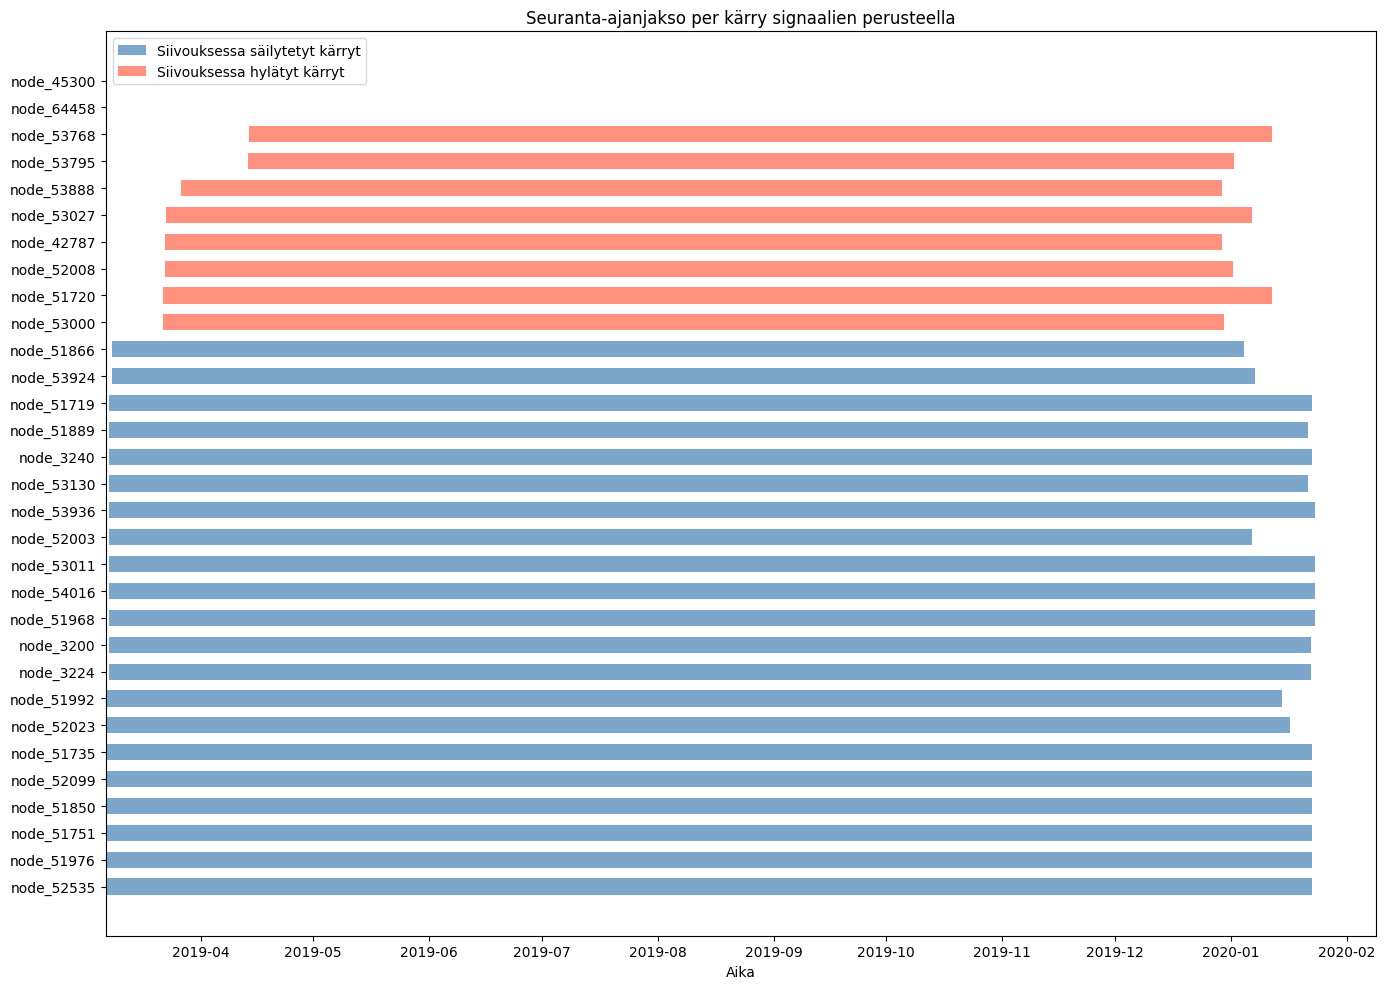

In [6]:
fig, ax = plt.subplots(figsize=(14, 10))

# Järjestetään kärryt alkamisajan mukaan
time_df_sorted = time_df.sort_values("aikaisin")

# Piirretään jana jokaiselle kärrylle
for i, row in enumerate(time_df_sorted.itertuples()):
    color = "tomato" if row.node in missing_nodes else "steelblue"
    ax.barh(row.node, 
            (row.myöhäisin - row.aikaisin).days, 
            left=row.aikaisin, 
            color=color, 
            alpha=0.7,
            height=0.6)

# Selite
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", alpha=0.7, label="Siivouksessa säilytetyt kärryt"),
    Patch(facecolor="tomato", alpha=0.7, label="Siivouksessa hylätyt kärryt")
]
ax.legend(handles=legend_elements)

ax.set_xlabel("Aika")
ax.set_title("Seuranta-ajanjakso per kärry signaalien perusteella")
plt.tight_layout()
plt.show()

### Analyysi

ETL-prosessissa hylätyissä kärryissä signaaleja on lyhyemmältä ajalta kuin säilytetyissä kärryissä.

### 4. Visualisoidaan raakadatan koordinaattijakauma

Pisteitä myymäläalueella: 139,544,181


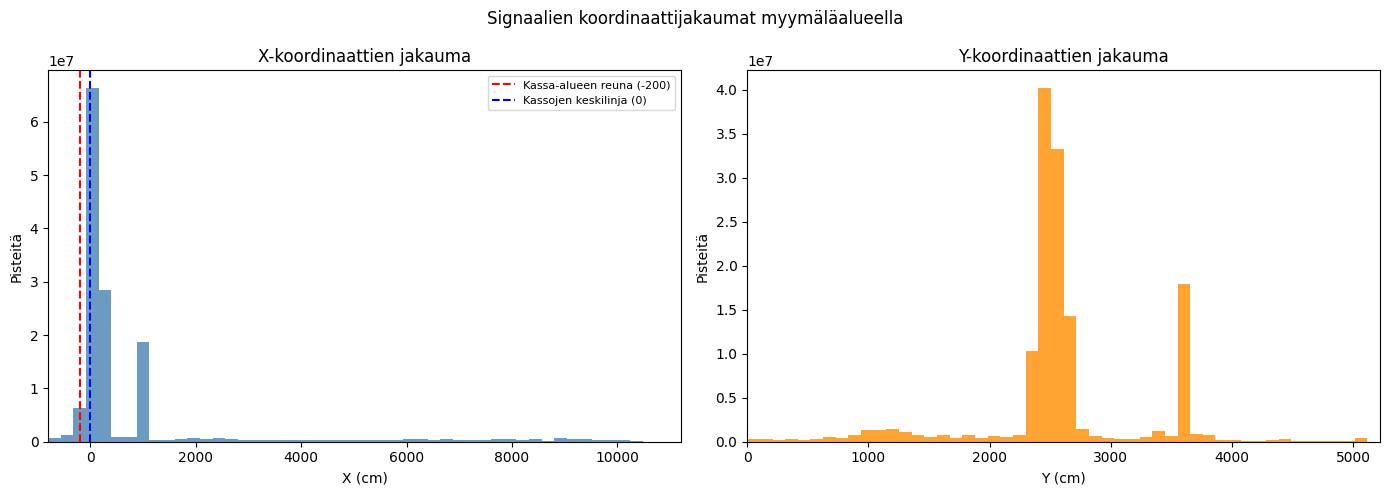

In [7]:
# Lasketaan histogrammiarvot tiedosto kerrallaan
bins_x = np.linspace(-800, store_max_x, 51)  # 50 pylvästä
bins_y = np.linspace(0, store_max_y, 51)

counts_x = np.zeros(50)
counts_y = np.zeros(50)
total_inside = 0

for f in raw_files:
    df = pd.read_csv(
        f,
        usecols=["x", "y"],  # ladataan vain x ja y
        dtype={"x": float, "y": float}
    )
    
    inside = df[
        (df["x"] >= -800) & (df["x"] <= store_max_x) &
        (df["y"] >= 0) & (df["y"] <= store_max_y)
    ]
    
    counts_x += np.histogram(inside["x"], bins=bins_x)[0]
    counts_y += np.histogram(inside["y"], bins=bins_y)[0]
    total_inside += len(inside)
    
    del df, inside

print(f"Pisteitä myymäläalueella: {total_inside:,}")

# Piirretään pylväsdiagrammi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(bins_x[:-1], counts_x, width=np.diff(bins_x), color="steelblue", alpha=0.8, align="edge")
axes[0].axvline(-200, color="red", linestyle="--", lw=1.5, label="Kassa-alueen reuna (-200)")
axes[0].axvline(0, color="blue", linestyle="--", lw=1.5, label="Kassojen keskilinja (0)")
axes[0].set_xlabel("X (cm)")
axes[0].set_ylabel("Pisteitä")
axes[0].set_title("X-koordinaattien jakauma")
axes[0].set_xlim(-800, store_max_x)
axes[0].legend(fontsize=8)

axes[1].bar(bins_y[:-1], counts_y, width=np.diff(bins_y), color="darkorange", alpha=0.8, align="edge")
axes[1].set_xlabel("Y (cm)")
axes[1].set_ylabel("Pisteitä")
axes[1].set_title("Y-koordinaattien jakauma")
axes[1].set_xlim(0, store_max_y)

plt.suptitle("Signaalien koordinaattijakaumat myymäläalueella")
plt.tight_layout()
plt.show()

### Analyysi

Paikannussignaaleja myymäläalueella on yhteensä 139 544 181.

X-koordinaatit:
- Valtava piikki kohdassa 0–500 cm. Kassajono, latauspiste ja sisäänkäynti sijoittuvat tähän.
- Pieni piikki noin 1000 cm kohdalla
- Osastoilla huomattavasti vähemmän signaaleja

Y-koordinaatit:
- Selvä piikki 2000–3000 cm, tässä kohtaa on latauspiste jonka ohi kuljetaan sisään myymälään
- Toinen merkittävä piikki noin 3500 cm

In [8]:
# Määritetään myymäläalueen rajat vastaamaan myymälän kokonaisleveyttä (11206 cm).
img_x_min = -800
img_x_max = 10406
img_y_min = 0
img_y_max = 5220

# Luodaan extent-lista Matplotlibiä varten
# Järjestys: [vasen, oikea, ala, ylä] -> y-akseli käännettynä (0 ylhäällä)
EXT = [img_x_min, img_x_max, img_y_max, img_y_min]

print(f"Raakadatan rajat asetettu:")
print(f"X: {img_x_min} ... {img_x_max} (leveys: {img_x_max - img_x_min} cm)")
print(f"Y: {img_y_min} ... {img_y_max} (korkeus: {img_y_max - img_y_min} cm)")
print(f"EXT: {EXT}")

Raakadatan rajat asetettu:
X: -800 ... 10406 (leveys: 11206 cm)
Y: 0 ... 5220 (korkeus: 5220 cm)
EXT: [-800, 10406, 5220, 0]


### 5. Visualisoidaan raakadatan heatmap myymälän pohjakarttaan

Heatmap muodostettu ✓


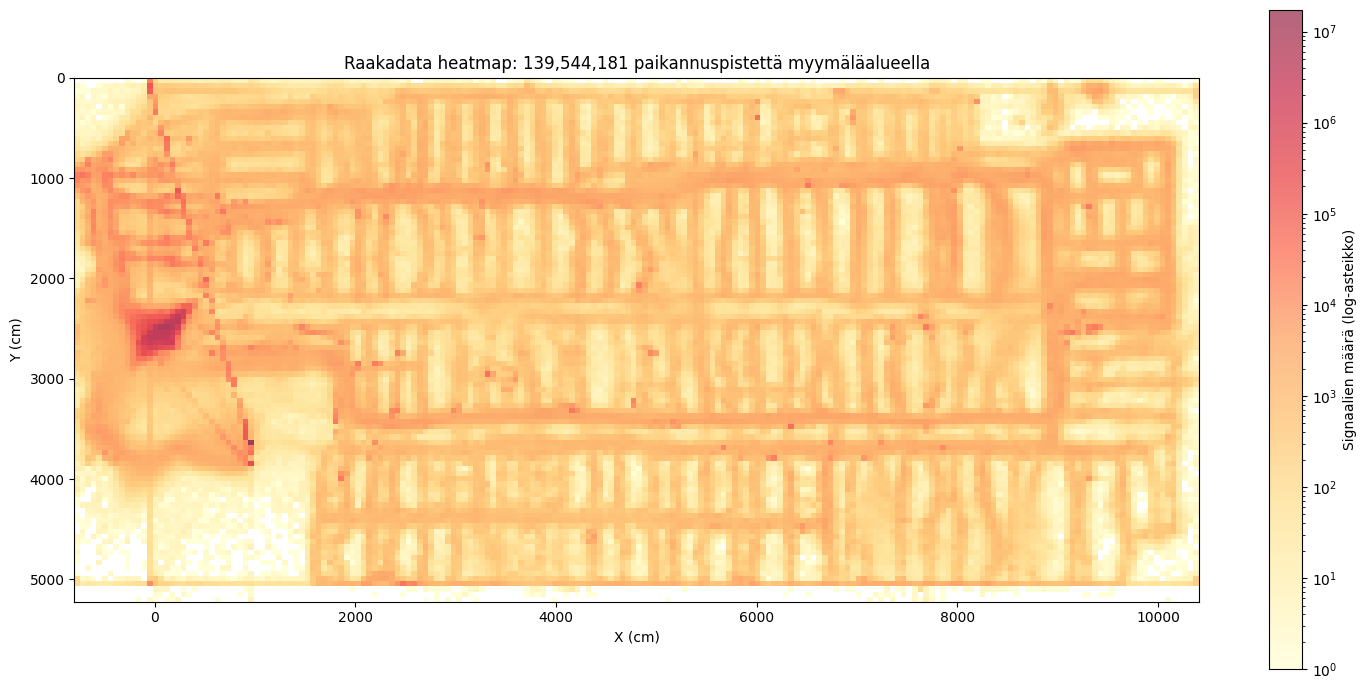

In [9]:
# Ladataan pohjakartta
img_path = os.path.join(project_root, "kauppa.jpg")
img = Image.open(img_path)

# Lasketaan 2D-histogrammi tiedosto kerrallaan
bins_x = np.linspace(img_x_min, img_x_max, 201)
bins_y = np.linspace(img_y_min, img_y_max, 101)
heatmap = np.zeros((len(bins_y) - 1, len(bins_x) - 1))

for f in raw_files:
    df = pd.read_csv(
        f,
        usecols=["x", "y"],
        dtype={"x": float, "y": float}
    )
    
    inside = df[
         (df["x"] >= img_x_min) & (df["x"] <= img_x_max) &
         (df["y"] >= img_y_min) & (df["y"] <= img_y_max)
    ]
    
    h, _, _ = np.histogram2d(inside["x"], inside["y"], bins=[bins_x, bins_y])
    heatmap += h.T
    
    del df, inside

print(f"Heatmap muodostettu ✓")

# Piirretään
fig, ax = plt.subplots(figsize=(15, 7))

ax.imshow(heatmap, extent=EXT, origin='upper', cmap='YlOrRd', alpha=0.4, norm=LogNorm(vmin=10, vmax=heatmap.max()))

im = ax.imshow(
    heatmap,
    extent=EXT,
    origin="upper",
    cmap="YlOrRd",
    alpha=0.6,
    norm=LogNorm(),
    aspect="equal"
)

plt.colorbar(im, ax=ax, label="Signaalien määrä (log-asteikko)")
ax.set_xlim(img_x_min, img_x_max)
ax.set_ylim(img_y_max, img_y_min)
ax.set_xlabel("X (cm)")
ax.set_ylabel("Y (cm)")
ax.set_title(f"Raakadata heatmap: {total_inside:,} paikannuspistettä myymäläalueella")
plt.tight_layout()
plt.show()

### Analyysi
- Kohdassa (0, 2600) näkyy kartan tummin alue, jossa kärryt seisovat latauksessa. Koska ne lähettävät signaalia paikallaan ollessaan, dataa kertyy siihen huomattavasti enemmän kuin muualle myymälään.
- Kassoilta alas oikealle kulkee tumma haamuviiva. Järjestelmä on todennäköisesti kadottanut kärryn hetkeksi ja piirtänyt suoran viivan kahden pisteen välille tai metallirakenteet ovat heijastaneet signaalia luoden kohinaa.
- Heatmapin yleiskuva vastaa siivottua dataa eli siivouksessa ei ole pudonnut mitään oleellista pois
- Käytävät ja vilkkaimmat kassat erottuvat selkeästi

### 6. Tutkitaan paljonko datassa on negatiivisia x-arvoja

In [10]:
# Tarkistetaan kuinka paljon dataa on negatiivisilla x-arvoilla
negative_x_count = 0
total_count = 0

for f in raw_files:
    df = pd.read_csv(
        f,
        usecols=["x"],
        dtype={"x": float}
    )
    negative_x_count += (df["x"] < 0).sum()
    total_count += len(df)
    del df

print(f"Signaaleja yhteensä: {total_count:,}")
print(f"Negatiivisia x-arvoja: {negative_x_count:,}")
print(f"Osuus: {round(negative_x_count / total_count * 100, 1)}%")

Signaaleja yhteensä: 139,961,560
Negatiivisia x-arvoja: 24,311,838
Osuus: 17.4%


### 7. Tutkitaan negatiivisten x-arvojen jakauma

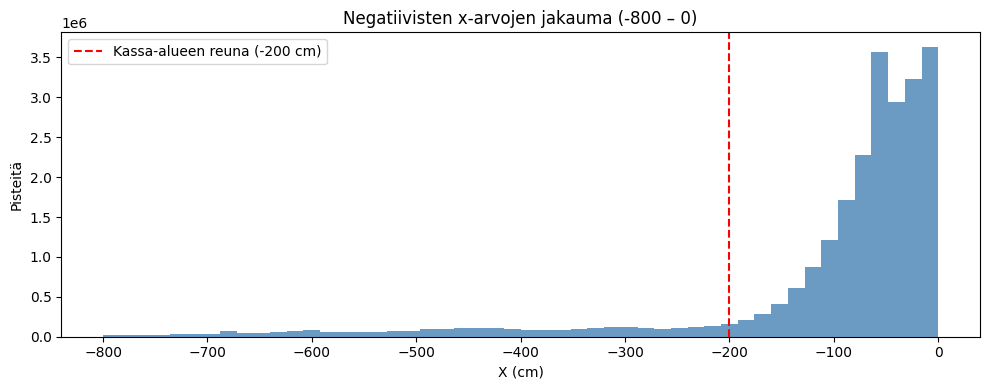

In [11]:
# Tutkitaan negatiivisten x-arvojen jakauma
bins_neg = np.linspace(-800, 0, 51)
counts_neg = np.zeros(50)

for f in raw_files:
    df = pd.read_csv(
        f,
        usecols=["x"],
        dtype={"x": float}
    )
    
    neg = df[(df["x"] >= -800) & (df["x"] < 0)]
    counts_neg += np.histogram(neg["x"], bins=bins_neg)[0]
    del df, neg

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(bins_neg[:-1], counts_neg, width=np.diff(bins_neg), color="steelblue", alpha=0.8, align="edge")
ax.set_xlabel("X (cm)")
ax.set_ylabel("Pisteitä")
ax.set_title("Negatiivisten x-arvojen jakauma (-800 – 0)")
ax.axvline(-200, color="red", linestyle="--", lw=1.5, label="Kassa-alueen reuna (-200 cm)")
ax.legend()
plt.tight_layout()
plt.show()

### Analyysi

X-akselin 0 on kassojen keskilinja. Koska paikannussignaaleja on merkittävä määrä kassojen keskilinjan vasemmalla puolella, voidaan arvioida että kassa-alue ulottuu noin kaksi metriä keskilinjasta vasemmalle ja myymälän seinä sijaitsee 5-7 metrin päässä kassojen keskilinjasta.

Kassojen keskilinjan jälkeen vasemmalla signaalimäärä on korkea. Se poistetaan ETL-prosessissa, jotta se ei vääristä analyysia.

### 8. Tutkitaan miten signaalit jakautuvat eri viikonpäiville

/tmp/ipykernel_2697709/1135183492.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_akseli, y=y_akseli, palette='viridis')


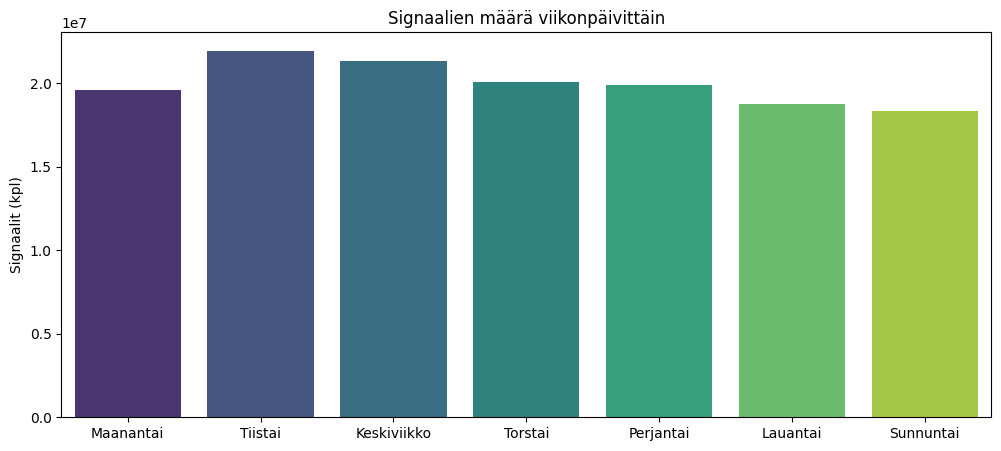

In [12]:
# Luodaan sanakirja, johon kerätään laskut (0=Ma, 1=Ti, jne.)
viikonpaiva_summat = {i: 0 for i in range(7)}

# Luetaan tiedostot yksi kerrallaan
for f in raw_files:
    # Luetaan vain tarvittava sarake muistin säästämiseksi
    temp_df = pd.read_csv(f, usecols=["timestamp"], dtype={"timestamp": str})
    
    # Muutetaan aikamuotoon ja lasketaan päivät tästä tiedostosta
    temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])
    counts = temp_df['timestamp'].dt.dayofweek.value_counts()
    
    # Lisätään tulokset pääsanakirjaan
    for day, count in counts.items():
        viikonpaiva_summat[day] += count
    
    # Vapautetaan muistia
    del temp_df

# Muutetaan tulokset kaaviota varten
paivat_fi = ['Maanantai', 'Tiistai', 'Keskiviikko', 'Torstai', 'Perjantai', 'Lauantai', 'Sunnuntai']
x_akseli = [paivat_fi[i] for i in range(7)]
y_akseli = [viikonpaiva_summat[i] for i in range(7)]

# Piirretään kaavio
plt.figure(figsize=(12, 5))
sns.barplot(x=x_akseli, y=y_akseli, palette='viridis')
plt.title('Signaalien määrä viikonpäivittäin')
plt.ylabel('Signaalit (kpl)')
plt.show()

### Analyysi

Raakadatassa tiistaina signaalien määrä on suurin. Keskiviikko on lähes yhtä vilkas kuin maanantai.

### 9. Tutkitaan signaalimääriä päivätasolla mittausajanjakson aikana

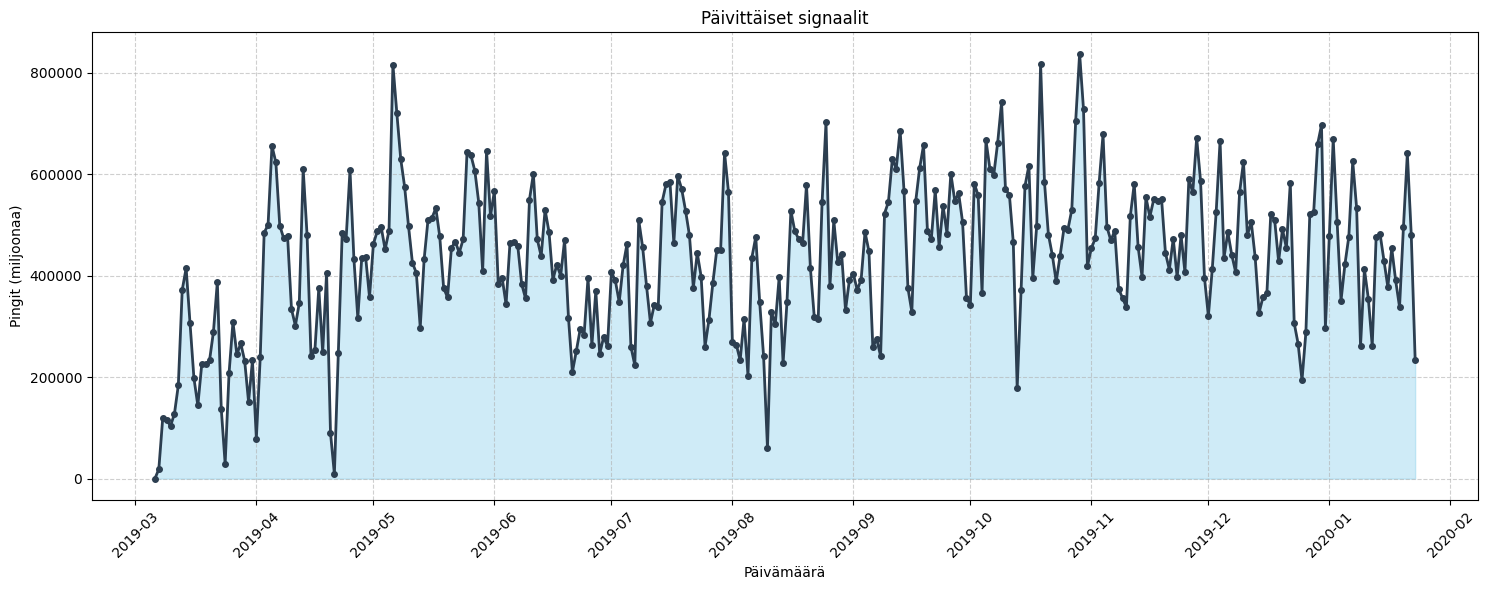

In [13]:
# Sanakirja päiväkohtaisille summille
paiva_summat = {}

for f in raw_files:
    # Luetaan vain timestamp muistin säästämiseksi
    temp_df = pd.read_csv(f, usecols=["timestamp"], dtype={"timestamp": str})
    temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])
    
    # Lasketaan havainnot per päivä (date-osa)
    counts = temp_df['timestamp'].dt.date.value_counts()
    
    for d, count in counts.items():
        paiva_summat[d] = paiva_summat.get(d, 0) + count
    
    del temp_df

# Muutetaan DataFrameksi ja järjestetään
daily_df = pd.DataFrame(list(paiva_summat.items()), columns=['Päivä', 'Pingit']).sort_values('Päivä')

# Piirretään käyrädiagrammi
plt.figure(figsize=(15, 6))
plt.plot(daily_df['Päivä'], daily_df['Pingit'], marker='o', linestyle='-', color='#2c3e50', linewidth=2, markersize=4)

# Korostetaan juhlapyhiä tai poikkeamia täyttämällä alue
plt.fill_between(daily_df['Päivä'], daily_df['Pingit'], color='skyblue', alpha=0.4)

plt.title('Päivittäiset signaalit')
plt.xlabel('Päivämäärä')
plt.ylabel('Pingit (miljoonaa)')
plt.grid(True, linestyle='--', alpha=0.6)

# Muotoillaan päivämäärät näkymään nätisti
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analyysi

Verrattaessa raakadatan päivittäistä volyymia siivottuun ostossessiodataan, tehdään seuraavat havainnot:

| Havainto | Raakadata (Signaalit) | Siivottu data (Sessiot) |
| :--- | :--- | :--- |
| **Volyymi** | Miljoonia signaaleja (perustaso n. 400k-600k) | Yksittäisiä kymmeniä sessioita |
| **Tekniset katkot** | Selkeät pudotukset nollaan (datayhteys poikki) | Näkyy puuttuvina päivinä |
| **Trendi** | Tasainen, korkea kohina läpi vuoden | Selkeämpiä sesonkivaihteluita |

**Johtopäätös:** Raakadata sisältää valtavasti staattista signaalia (latauspisteet), joka nostaa perustason korkealle, vaikka kaupassa olisi hiljaista.

Selkeä kausiluonteinen kaava: huhtikuussa 2019 vilkastuu, toukokuun 2019 alkupuolella (äitienpäivä?) valtava piikki, heinä-elokuu selvästi hiljaisempi jakso, lokakuu 2019 eteenpäin korkeampi ja tasaisempi taso.

### 10. Tutkitaan signaalien jakaumaa tunneittain

  1/31 valmis
  2/31 valmis
  3/31 valmis
  4/31 valmis
  5/31 valmis
  6/31 valmis
  7/31 valmis
  8/31 valmis
  9/31 valmis
  10/31 valmis
  11/31 valmis
  12/31 valmis
  13/31 valmis
  14/31 valmis
  15/31 valmis
  16/31 valmis
  17/31 valmis
  18/31 valmis
  19/31 valmis
  20/31 valmis
  21/31 valmis
  22/31 valmis
  23/31 valmis
  24/31 valmis
  25/31 valmis
  26/31 valmis
  27/31 valmis
  28/31 valmis
  29/31 valmis
  30/31 valmis
  31/31 valmis


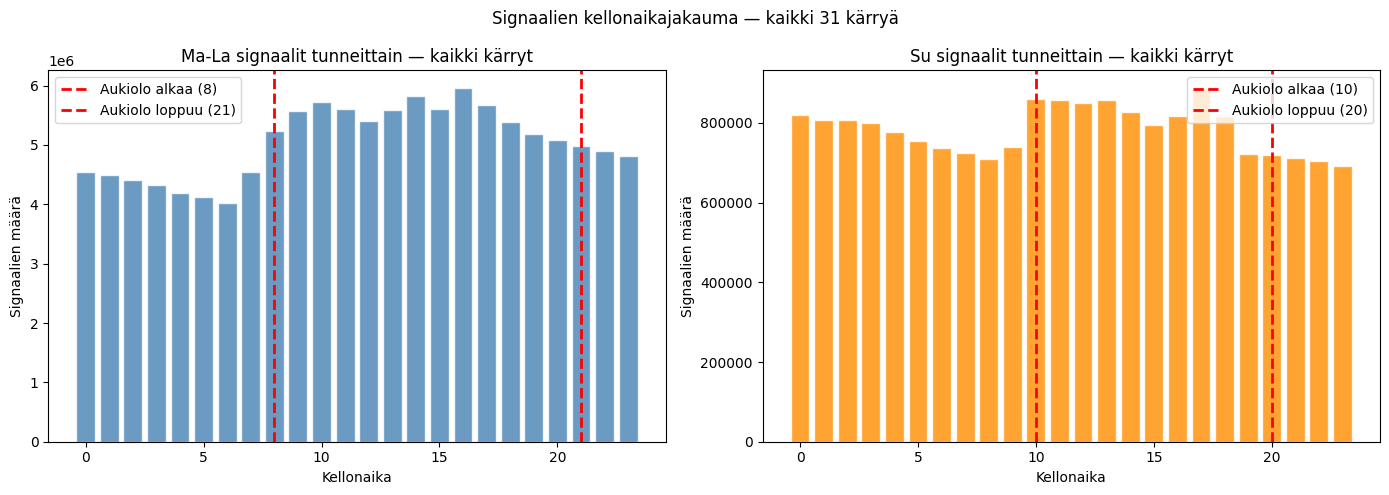

In [14]:
# Kerätään tuntijakaumat tiedosto kerrallaan
counts_mon_sat = np.zeros(24)
counts_sun = np.zeros(24)
total_files = len(raw_files)

for i, f in enumerate(raw_files):
    df = pd.read_csv(
        f,
        usecols=["timestamp"],
        dtype={"timestamp": str}
    )
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
    df["timestamp_local"] = df["timestamp"].dt.tz_convert("Europe/Helsinki")
    df["hour"] = df["timestamp_local"].dt.hour
    df["weekday"] = df["timestamp_local"].dt.dayofweek
    
    counts_mon_sat += np.histogram(df[df["weekday"] < 6]["hour"], bins=24, range=(0, 24))[0]
    counts_sun += np.histogram(df[df["weekday"] == 6]["hour"], bins=24, range=(0, 24))[0]
    
    del df
    print(f"  {i+1}/{total_files} valmis")

mon_sat_start, mon_sat_end = store_config["operational_hours"]["mon-sat"]
sun_start, sun_end = store_config["operational_hours"]["sun"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(24), counts_mon_sat, color="steelblue", alpha=0.8, edgecolor="white")
axes[0].axvline(mon_sat_start, color="red", linestyle="--", lw=2, label=f"Aukiolo alkaa ({mon_sat_start})")
axes[0].axvline(mon_sat_end, color="red", linestyle="--", lw=2, label=f"Aukiolo loppuu ({mon_sat_end})")
axes[0].set_xlabel("Kellonaika")
axes[0].set_ylabel("Signaalien määrä")
axes[0].set_title("Ma-La signaalit tunneittain — kaikki kärryt")
axes[0].legend()

axes[1].bar(range(24), counts_sun, color="darkorange", alpha=0.8, edgecolor="white")
axes[1].axvline(sun_start, color="red", linestyle="--", lw=2, label=f"Aukiolo alkaa ({sun_start})")
axes[1].axvline(sun_end, color="red", linestyle="--", lw=2, label=f"Aukiolo loppuu ({sun_end})")
axes[1].set_xlabel("Kellonaika")
axes[1].set_ylabel("Signaalien määrä")
axes[1].set_title("Su signaalit tunneittain — kaikki kärryt")
axes[1].legend()

plt.suptitle("Signaalien kellonaikajakauma — kaikki 31 kärryä")
plt.tight_layout()
plt.show()

### Analyysi

Ma-La:
- Signaaleja on ympäri vuorokauden, myös aukioloajan ulkopuolella klo 0-8 ja 21-24
- Eniten signaaleja on aukioloaikana klo 8-21 ja vähiten klo 5-6.

Su:
- Sama ilmiö, signaaleja ympäri vuorokauden
- Aukioloaikana klo 10-18 signaaleja, vähiten klo 19-23 ja klo 8

### 10. Tutkitaan kärryjen nopeusjakaumaa

In [44]:
all_speeds = []

for f in raw_files:
    # Luetaan tarvittavat sarakkeet
    temp_df = pd.read_csv(f, usecols=["node_id", "timestamp", "x", "y"])
    temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])
    
    # Järjestetään kärryittäin ja aikajärjestykseen
    temp_df = temp_df.sort_values(['node_id', 'timestamp'])
    
    # Lasketaan erotukset peräkkäisten rivien välillä (samalle node_id:lle)
    # diff() laskee eron edelliseen riviin
    temp_df['dt'] = temp_df.groupby('node_id')['timestamp'].diff().dt.total_seconds()
    temp_df['dx'] = temp_df.groupby('node_id')['x'].diff()
    temp_df['dy'] = temp_df.groupby('node_id')['y'].diff()
    
    # Lasketaan etäisyys (cm) ja nopeus (cm/s)
    temp_df['dist'] = np.sqrt(temp_df['dx']**2 + temp_df['dy']**2)
    
    # Vältetään nollalla jakaminen
    temp_df['speed'] = temp_df['dist'] / temp_df['dt']
    
    # Poistetaan NaN-arvot (jokaisen kärryn ensimmäinen piste) ja mahdottomat dt=0 tilanteet
    speeds = temp_df['speed'].dropna()
    speeds = speeds[np.isfinite(speeds)] # Poistetaan äärettömät
    
    all_speeds.append(speeds)
    del temp_df

# Yhdistetään nopeudet yhteen listaan analyysia varten
combined_speeds = pd.concat(all_speeds)

In [45]:
# 1. Lasketaan raakadatan maksiminopeus (cm/s -> m/s)
raw_max_speed = combined_speeds.max() / 100
raw_avg_speed = combined_speeds.mean() / 100

print(f"--- Raakadatan nopeustilastot ---")
print(f"Suurin havaittu yksittäinen nopeus: {raw_max_speed:.2f} m/s")
print(f"Koko datan keskiarvonopeus: {raw_avg_speed:.4f} m/s")
print(f"---------------------------------\n")

# 2. Määritetään kärrykohtaiset keskiarvot
# Koska all_speeds on lista jokaisen tiedoston nopeuksista, lasketaan keskiarvo per tiedosto
node_averages = [s.mean() / 100 for s in all_speeds]
max_node_avg = max(node_averages)

print(f"Kärrykohtaiset keskiarvot (m/s):")
print(f"- Pienin keskiarvo: {min(node_averages):.4f} m/s")
print(f"- Suurin keskiarvo: {max_node_avg:.4f} m/s")

# 3. Ehdotus suodattimeksi
print(f"\n--- Analyysi ---")
print(f"Raakadatan perusteella kärryjen maksimikeskiarvonopeus on {max_node_avg:.2f} m/s.")
print(f"Nykyinen suodatinasetuksesi (1.5 m/s) on hyvin turvallinen.")

--- Raakadatan nopeustilastot ---
Suurin havaittu yksittäinen nopeus: 307795849.22 m/s
Koko datan keskiarvonopeus: 273.9595 m/s
---------------------------------

Kärrykohtaiset keskiarvot (m/s):
- Pienin keskiarvo: 0.0003 m/s
- Suurin keskiarvo: 652.6853 m/s

--- Analyysi ---
Raakadatan perusteella kärryjen maksimikeskiarvonopeus on 652.69 m/s.
Nykyinen suodatinasetuksesi (1.5 m/s) on hyvin turvallinen.


In [ ]:
import gc

# Kerätään vain otos nopeuksista, jotta saamme kuvan tilanteesta nopeasti
all_speeds = []

# Käsitellään vain ensimmäiset 5 tiedostoa
for f in raw_files[:5]: 
    # Luetaan vain tarvittavat, ja määritetään aikaleima heti
    temp_df = pd.read_csv(f, usecols=["node_id", "timestamp", "x", "y"])
    temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])
    
    # Järjestys on välttämätön
    temp_df.sort_values(['node_id', 'timestamp'], inplace=True)
    
    # Käytetään shiftiä groupbyn sijasta (nopeampi jos data on järjestetty)
    # Lasketaan erotukset vain jos node_id on sama kuin edellisellä rivillä
    same_node = temp_df['node_id'] == temp_df['node_id'].shift(1)
    
    dt = (temp_df['timestamp'] - temp_df['timestamp'].shift(1)).dt.total_seconds()
    dx = temp_df['x'] - temp_df['x'].shift(1)
    dy = temp_df['y'] - temp_df['y'].shift(1)
    
    # Lasketaan nopeus vain riveille, joissa edellinen piste oli samaa kärryä
    dist = np.sqrt(dx**2 + dy**2)
    speed = dist / dt
    
    # Otetaan talteen vain järkevät arvot
    valid_speeds = speed[same_node & (dt > 0) & (dt < 60)] # dt < 60s rajoittaa hyppyjä
    all_speeds.append(valid_speeds.dropna())

    gc.collect()

combined_speeds = pd.concat(all_speeds)
print("Valmis! Nyt voit ajaa histogrammi-solun.")

Valmis! Nyt voit ajaa histogrammi-solun.


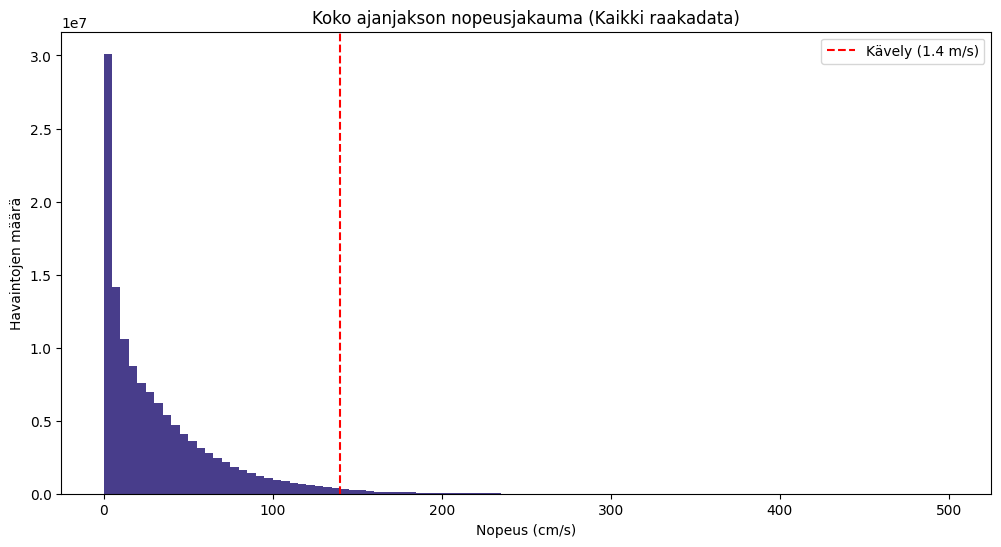

In [20]:
# Määritetään histogrammin rajat valmiiksi (esim. 0-500 cm/s, 100 lohkoa)
bins = np.linspace(0, 500, 101)
kokonais_counts = np.zeros(len(bins)-1)

for f in raw_files:
    # Luetaan vain tarvittavat
    temp_df = pd.read_csv(f, usecols=["node_id", "timestamp", "x", "y"])
    temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])
    temp_df.sort_values(['node_id', 'timestamp'], inplace=True)
    
    # Lasketaan nopeus
    same_node = temp_df['node_id'] == temp_df['node_id'].shift(1)
    dt = (temp_df['timestamp'] - temp_df['timestamp'].shift(1)).dt.total_seconds()
    dist = np.sqrt(temp_df['x'].diff()**2 + temp_df['y'].diff()**2)
    
    # Suodatetaan nollat ja teleportit pois tässä vaiheessa
    speed = dist / dt
    valid_speeds = speed[same_node & (dt > 0.1) & (dt < 60)].dropna()
    
    # Lasketaan histogrammi tästä tiedostosta ja lisätään se kokonaissummaan
    counts, _ = np.histogram(valid_speeds, bins=bins)
    kokonais_counts += counts
    
    del temp_df

# Piirretään koko datan histogrammi
plt.figure(figsize=(12, 6))
plt.bar(bins[:-1], kokonais_counts, width=np.diff(bins), align='edge', color='darkslateblue')
plt.axvline(x=140, color='red', linestyle='--', label='Kävely (1.4 m/s)')
plt.title('Koko ajanjakson nopeusjakauma (Kaikki raakadata)')
plt.xlabel('Nopeus (cm/s)')
plt.ylabel('Havaintojen määrä')
plt.legend()
plt.show()

### Analyysi

Datan volyymi: Raakadata on valtavaa (yli 30 miljoonaa havaintoa), mutta noin 80 % siitä on teknistä kohinaa tai paikallaan seisomista (pylvään huippu (0–5 cm/s).

Anomaliat: Ilman suodatusta kärryt näyttävät liikkuvan jopa neljäsosalla valonnopeudesta, mikä selittää aiemman heatmapin hyllyjen läpi kulkevat "haamuviivat".

Käyttäytyminen: Asiakkaat liikkuvat kärryn kanssa hyvin hitaasti, pääosin 20-60 cm/s. He pysähtelevät hyllyjen välissä jatkuvasti.

### 11. Tutkitaan paikannussignaalien välisiä matkoja

In [40]:
# Oletetaan, että timestamp on datetime-muodossa
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 1. Lasketaan aikaero sekunteina
df['dt'] = df['timestamp'].diff().dt.total_seconds()

# 2. Lasketaan etäisyys metreinä (jos alkup. data on cm, jaetaan 100:lla)
df['dist_m'] = np.sqrt(df['x'].diff()**2 + df['y'].diff()**2) / 100

# 3. Lasketaan nopeus m/s
# Täytetään ensimmäinen rivi nollalla tai NaN:lla, ettei tule jakoa nollalla
df['speed_ms'] = df['dist_m'] / df['dt']

# 4. Suodatetaan pois liian nopeat haamuhypyt
limit = 2.78  # max_jump_speed_ms
df_cleaned = df[df['speed_ms'] <= limit].copy()

print(f"Rivejä ennen: {len(df)}, Rivejä siivouksen jälkeen: {len(df_cleaned)}")

Rivejä ennen: 4967778, Rivejä siivouksen jälkeen: 4923384


Tilastot paikannuspisteiden välisistä etäisyyksistä (cm):
count    4.967777e+06
mean     5.434280e+01
std      5.966795e+02
min      0.000000e+00
25%      0.000000e+00
50%      1.140175e+01
75%      3.801316e+01
max      4.701551e+04
Name: dist, dtype: float64


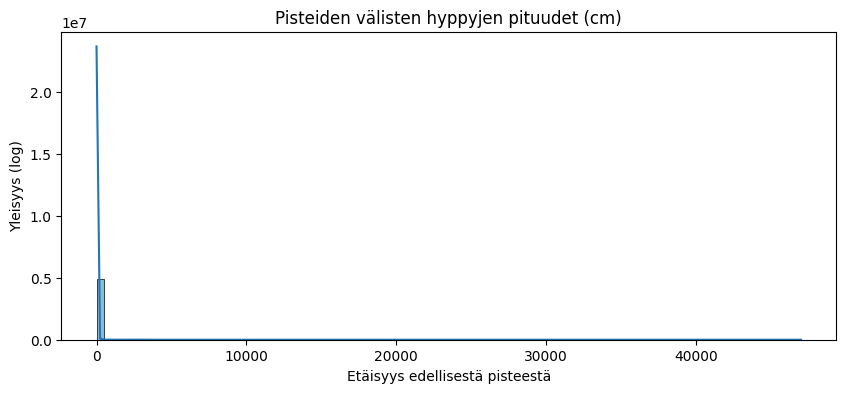

In [42]:
# 1. Lasketaan etäisyys peräkkäisten pisteiden välillä
# .diff() laskee eron nykyisen ja edellisen rivin välillä
df['dist'] = np.sqrt(df['x'].diff()**2 + df['y'].diff()**2)

# 2. Tarkistetaan perusstatistiikka etäisyyksille
print("Tilastot paikannuspisteiden välisistä etäisyyksistä (cm):")
print(df['dist'].describe())

# 3. Visualisoidaan hyppyjen jakautuma
plt.figure(figsize=(10, 4))
sns.histplot(df['dist'].dropna(), bins=100, kde=True)
plt.title('Pisteiden välisten hyppyjen pituudet (cm)')
plt.xlabel('Etäisyys edellisestä pisteestä')
plt.ylabel('Yleisyys (log)')
plt.show()

# 4. Esimerkki suodatuksesta: pidetään vain "loogiset" liikkeet
# Jos tiedämme että kärry ei liiku esim. yli 300 cm (3m) sekunnissa
# (Tämä vaatii että tiedät näytteenottotaajuuden, esim. 1s)
reasonable_jump_limit = 500 # cm
filtered_df = df[df['dist'] < reasonable_jump_limit]

### Analyysi

1. Kärry ei liiku (25 % kvartiili = 0)
Alin 25 % kaikista havainnoista on tarkalleen 0 cm. Tämä tarkoittaa, että kärry on joko täysin paikallaan tai järjestelmä ei ole rekisteröinyt liikettä mittausten välillä. Tämä sopii hyvin yhteen latauspisteen ja hyllyjen välissä seisomisen kanssa.

2. Normaali liike (Mediaani = 11.4 cm)
Mediaanihyppy on noin 11 cm. Jos näytteenottotaajuus on esimerkiksi 1 sekunti, tämä vastaa hidasta ja luonnollista siirtymistä myymälässä. Myös 75 % kvartiili (38 cm) on vielä täysin järkevän kävelyvauhdin rajoissa.

3. Tekninen virhe (Max = 47 015 cm)
Maksimiarvo on peräti 470 metriä yhdellä mittausvälillä! Tämä on se "vino viiva" ja muut haamupisteet. Kärry ei tietenkään liiku puolta kilometriä sekunnissa, joten kyseessä on puhtaasti signaalin heijastumisesta johtuva virhelukema.

Tämä kuvaaja todistaa, että suodatus on välttämätöntä. Jos raakadataa käytettäisiin sellaisenaan, latauspisteen painoarvo on niin valtava, että se peittää alleen kaiken muun. 47 000 cm hypyt ovat tilastollisia poikkeamia (outliers).